In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from itertools import combinations
from tqdm import tqdm

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from nnfabrik.utility.nn_helpers import set_random_seed

In [2]:
# loading the SENSORIUM+ dataset
pre = "/usr/users/agecker/datasets/sensorium_2022_pictures/real_dataset/"
filenames = [f"{pre}{i}/" for i in os.listdir(pre)]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
model_fn = 'sensorium.models.stacked_core_full_gauss_readout'
model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 10,
  'hidden_kern': 7,
  'hidden_channels': 128,
  'depth_separable': True,
  'grid_mean_predictor': {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
   },
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': True,
  'regularizer_type': 'adaptive_log_norm',
  #'feature_reg_weight': 10,
}
model_seed42 = get_model(
    model_fn=model_fn,
    model_config=model_config,
    dataloaders=dataloaders,
    seed=42,
)
model_seed10 = get_model(
    model_fn=model_fn,
    model_config=model_config,
    dataloaders=dataloaders,
    seed=10,
)
model_seed100 = get_model(
    model_fn=model_fn,
    model_config=model_config,
    dataloaders=dataloaders,
    seed=100,
)

KeyboardInterrupt: 

In [34]:
clusters=5
seed = 42
set_random_seed(seed)
predictions_dict = {}

starting_epcoch = 1
multiplier = 100000.0
exponent=2.0
clusters=5
alpha=2.1
pretrain_epoch = 13
lr_model=0.008
seeds = [10,100,42]

for seed in seeds:
    predictions_dict[seed] = {}
    path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
    predictions_dict[seed] =torch.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_dec_{path_ending}.pt').cpu().numpy()

In [4]:
predictions_dict = {}
seeds = [10,100,42]
clusters=18
for seed in seeds:
    predictions_dict[seed] = {}
    path_ending = f'{clusters}clusters_seed_{seed}'
    predictions_dict[seed] = np.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_GMM_without_KL_{path_ending}.npy')

In [5]:
predictions_dict

{10: array([ 7, 16, 13, ..., 11, 15, 16]),
 100: array([ 4,  4, 16, ...,  4,  2, 10]),
 42: array([ 4,  9,  2, ..., 12, 16,  9])}

In [35]:
ari_results = {}

# Iterate over all pairs of seeds
for seed1, seed2 in combinations(predictions_dict.keys(), 2):
    ari_score = adjusted_rand_score(predictions_dict[seed1], predictions_dict[seed2])
    ari_results[(seed1, seed2)] = ari_score
    print(f"ARI for PE: {pretrain_epoch}, clusters: {clusters}, mult: {multiplier} between seed {seed1} and seed {seed2}: {ari_score:.4f}")

# Output ARI results
ari_results

ARI for PE: 13, clusters: 5, mult: 100000.0 between seed 10 and seed 100: 0.3198
ARI for PE: 13, clusters: 5, mult: 100000.0 between seed 10 and seed 42: 0.2399
ARI for PE: 13, clusters: 5, mult: 100000.0 between seed 100 and seed 42: 0.2648


{(10, 100): 0.31982569877466804,
 (10, 42): 0.239910373741998,
 (100, 42): 0.26475436015308923}

In [17]:
alpha=2.1
clusters = list(range(5,10)) + list(range(10, 65, 5))
# [5,10,15,20,25,30]
seeds=[10,42,100]
ari_results = {}         # Stores ARI scores against ground truth
predictions_dict = {}    # Stores predicted labels
pretrain_epochs = np.array([5,10,20,30,40])
keys1 = np.array([1e4,5e4,1e5,1e7])
keys2 = range(5,55,5)
lr_model = 0.008

for k1 in keys1:
    predictions_dict[k1] = {}
    multiplier = k1
    print(multiplier)
    if multiplier == 1e7:
        lr_model= 0.005
    for k2 in keys2:
        predictions_dict[k1][k2] = {}
        cluster = k2
        for seed in seeds:
            path_ending = f'dec_KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
            #path_ending = f'GMM_without_KL_{cluster}clusters_seed_{seed}'
            save_path = f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_{path_ending}.pt'
            if not os.path.exists(save_path):
                print(f"Warning: Model file not found for {save_path}. Inserting None.")
                predictions_dict[k1][k2][seed] = np.nan
                continue  # Skip this iteration
            #model_seed42.load_state_dict(torch.load(save_path),strict=False)
            predictions_dict[k1][k2][seed] = torch.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_{path_ending}.pt').cpu().numpy()

10000.0
50000.0
100000.0
10000000.0


In [18]:
ari_results = {}  

for k1 in keys1:
    ari_results[k1] = {}  
    for k2 in keys2:
        ari_results[k1][k2] = {}
        for seed1, seed2 in combinations(seeds, 2):
            try:
                # Check if both seeds exist before computing ARI
                if (seed1 in predictions_dict[k1][k2] and 
                    seed2 in predictions_dict[k1][k2]):
                    
                    # Compute ARI
                    ari_score = adjusted_rand_score(
                        predictions_dict[k1][k2][seed1], 
                        predictions_dict[k1][k2][seed2]
                    )
                else:
                    ari_score = np.nan  
            except Exception as e:
                ari_score = np.nan  # Insert None in case of errors

            # Store result
            ari_results[k1][k2][(seed1, seed2)] = ari_score
            print(f"ARI between seed {seed1} and seed {seed2} for key1 {k1}, key2 {k2}: {ari_score}")


ARI between seed 10 and seed 42 for key1 10000.0, key2 5: 0.40006592219723314
ARI between seed 10 and seed 100 for key1 10000.0, key2 5: 0.41870190828978254
ARI between seed 42 and seed 100 for key1 10000.0, key2 5: 0.428316752264347
ARI between seed 10 and seed 42 for key1 10000.0, key2 10: 0.29058784839600243
ARI between seed 10 and seed 100 for key1 10000.0, key2 10: 0.33158311976735927
ARI between seed 42 and seed 100 for key1 10000.0, key2 10: 0.2731938448228639
ARI between seed 10 and seed 42 for key1 10000.0, key2 15: 0.2317714939250099
ARI between seed 10 and seed 100 for key1 10000.0, key2 15: 0.22840836446463542
ARI between seed 42 and seed 100 for key1 10000.0, key2 15: 0.18997599180171099
ARI between seed 10 and seed 42 for key1 10000.0, key2 20: 0.2107256995607229
ARI between seed 10 and seed 100 for key1 10000.0, key2 20: 0.23370932088444796
ARI between seed 42 and seed 100 for key1 10000.0, key2 20: 0.20905023244175314
ARI between seed 10 and seed 42 for key1 10000.0, ke

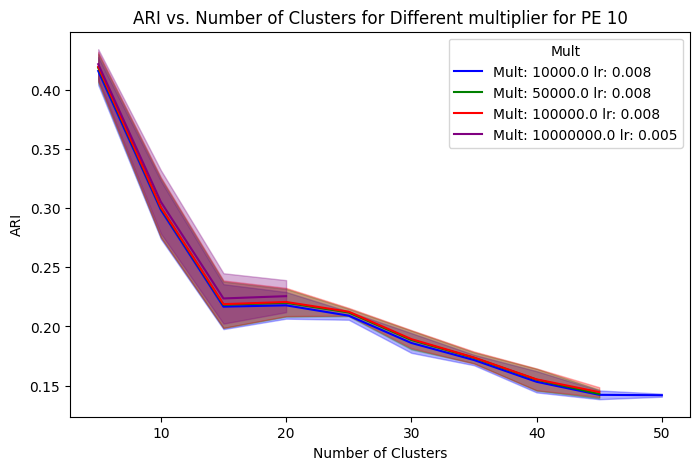

In [20]:
colors = ["blue", "green", "red", "purple", "orange"]  # Adjust as needed

plt.figure(figsize=(8, 5))

for i, k1 in enumerate(keys1):
    lr_model = 0.008
    if k1 == 1e7:
        lr_model = 0.005
    ari_values = [list(ari_results[k1][k2].values()) for k2 in keys2]

    # Filter out None values for mean and std calculation
    ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
    ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])

    plt.plot(keys2, ari_means, color=colors[i % len(colors)], label=f"Mult: {k1} lr: {lr_model}")

    valid_idx = [j for j, v in enumerate(ari_means) if v is not None]
    if valid_idx:  # Ensure there is at least one valid value
        plt.fill_between(
            np.array(keys2)[valid_idx], 
            ari_means[valid_idx] - ari_stds[valid_idx], 
            ari_means[valid_idx] + ari_stds[valid_idx], 
            color=colors[i % len(colors)], alpha=0.3
        )

# Labels & Legend
plt.xlabel("Number of Clusters")
plt.ylabel("ARI")
plt.legend(title="Mult")
plt.title(f"ARI vs. Number of Clusters for Different multiplier for PE 10")
plt.show()

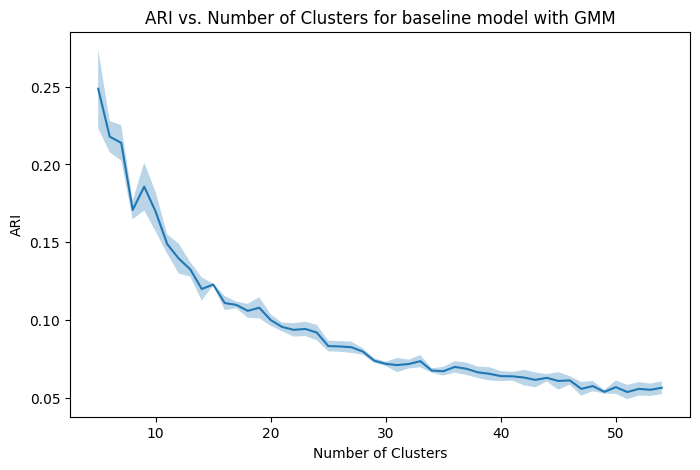

In [22]:
alpha=2.1
clusters = list(range(5,10)) + list(range(10, 65, 5))
# [5,10,15,20,25,30]
seeds=[10,42,100]
ari_results = {}         # Stores ARI scores against ground truth
predictions_dict = {}    # Stores predicted labels
pretrain_epochs = np.array([5,10,20,30,40])
keys1 = range(5,55)

for k1 in keys1:
    predictions_dict[k1] = {}
    cluster=k1
    for seed in seeds:
        path_ending = f'GMM_without_KL_{cluster}clusters_seed_{seed}'
        predictions_dict[k1][seed] = np.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_{path_ending}.npy')

ari_results = {}  

for k1 in keys1:
    ari_results[k1] = {}  
    for seed1, seed2 in combinations(seeds, 2):
        try:
            # Check if both seeds exist before computing ARI
            if (seed1 in predictions_dict[k1]and 
                seed2 in predictions_dict[k1]):
                ari_score = adjusted_rand_score(
                    predictions_dict[k1][seed1], 
                    predictions_dict[k1][seed2]
                )
            else:
                ari_score = np.nan  
        except Exception as e:
            ari_score = np.nan  # Insert None in case of errors

        # Store result
        ari_results[k1][(seed1, seed2)] = ari_score
        #print(f"ARI between seed {seed1} and seed {seed2} for key1 {k1}: {ari_score}")

colors = ["blue", "green", "red", "purple", "orange"]  # Adjust as needed

plt.figure(figsize=(8, 5))

ari_values = [list(ari_results[k1].values()) for k1 in keys1]

# Filter out None values for mean and std calculation
ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])

plt.plot(keys1, ari_means,  label=f"Mult: {k1} lr: {lr_model}")

valid_idx = [j for j, v in enumerate(ari_means) if v is not None]
if valid_idx:  # Ensure there is at least one valid value
    plt.fill_between(
        np.array(keys1)[valid_idx], 
        ari_means[valid_idx] - ari_stds[valid_idx], 
        ari_means[valid_idx] + ari_stds[valid_idx], 
        alpha=0.3
    )

# Labels & Legend
plt.xlabel("Number of Clusters")
plt.ylabel("ARI")
#plt.legend(title="Pretrain epochs")
plt.title(f"ARI vs. Number of Clusters for baseline model with GMM")
plt.show()

In [71]:
colors = ["blue", "green", "red", "purple", "orange"]  # Adjust as needed

plt.figure(figsize=(8, 5))

for i, pretrain_epoch in enumerate(pretrain_epochs):
    if pretrain_epoch == 10:
        lr_model = 0.005
        multiplier = 100000.0
    elif pretrain_epoch == 15:
        lr_model= 0.004
        multiplier = 100000.0
    elif pretrain_epoch == 5:
        lr_model=0.006
        multiplier= 1000000.0
    else:
        multiplier = 100000.0
        lr_model=0.003
    ari_values = [list(ari_results[pretrain_epoch][c].values()) for c in clusters]

    # Filter out None values for mean and std calculation
    ari_means = np.array([np.mean([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])
    ari_stds = np.array([np.std([v for v in vals if v is not None]) if any(v is not None for v in vals) else None for vals in ari_values])

    plt.plot(clusters, ari_means, color=colors[i % len(colors)], label=f"PE {pretrain_epoch} lr: {lr_model}")

    valid_idx = [j for j, v in enumerate(ari_means) if v is not None]
    if valid_idx:  # Ensure there is at least one valid value
        plt.fill_between(
            np.array(clusters)[valid_idx], 
            ari_means[valid_idx] - ari_stds[valid_idx], 
            ari_means[valid_idx] + ari_stds[valid_idx], 
            color=colors[i % len(colors)], alpha=0.3
        )

# Labels & Legend
plt.xlabel("Number of Clusters")
plt.ylabel("ARI")
plt.legend(title="Pretrain epochs")
plt.title(f"ARI vs. Number of Clusters for Different PEs")
plt.show()

KeyError: 5

<Figure size 800x500 with 0 Axes>

In [72]:
colors = ["blue", "green", "red", "purple", "orange"]  # Adjust as needed

plt.figure(figsize=(8, 5))

# Iterate over each alpha and plot ARI values
for i, alpha in enumerate(pretrain_epochs):
    ari_means = np.array([np.mean(list(ari_results[alpha][c].values())) for c in clusters])
    ari_stds = np.array([np.std(list(ari_results[alpha][c].values())) for c in clusters])

    plt.plot(clusters, ari_means, color=colors[i % len(colors)], label=f"Alpha {alpha}")
    plt.fill_between(clusters, ari_means - ari_stds, ari_means + ari_stds, 
                     color=colors[i % len(colors)], alpha=0.3)

# Labels & Legend
plt.xlabel("Number of Clusters")
plt.ylabel("ARI")
plt.legend(title="Alpha Values")
plt.title(f"ARI vs. Number of Clusters for Different Alphas for PE: {pretrain_epoch}, lr: {lr_model}")
plt.show()

KeyError: 5

<Figure size 800x500 with 0 Axes>

In [53]:
seed = 10
path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_{path_ending}.pth'
model_seed10.load_state_dict(torch.load(save_path),strict=False)
predictions_10 = torch.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_dec_{path_ending}.pt').cpu().numpy()
seed = 100
path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_{path_ending}.pth'
model_seed100.load_state_dict(torch.load(save_path),strict=False)
predictions_100 = torch.load(f'/user/ninasophie.nellen/sensorium/tests/predictions/predictions_dec_{path_ending}.pt').cpu().numpy()

In [54]:
predictions_dict = {
    42: predictions_42,
    10: predictions_10,
    100: predictions_100
}

# Compute ARI scores between different seeds
ari_results = {}

# Iterate over all pairs of seeds
for seed1, seed2 in combinations(predictions_dict.keys(), 2):
    ari_score = adjusted_rand_score(predictions_dict[seed1], predictions_dict[seed2])
    ari_results[(seed1, seed2)] = ari_score
    print(f"ARI between seed {seed1} and seed {seed2}: {ari_score:.4f}")

# Output ARI results
ari_results

ARI between seed 42 and seed 10: 0.1522
ARI between seed 42 and seed 100: 0.1710
ARI between seed 10 and seed 100: 0.1940


{(42, 10): 0.15216958400715988,
 (42, 100): 0.17100023703420453,
 (10, 100): 0.19402112275611832}

In [55]:
features_list_42 = []  # Features for model_seed42
features_list_10 = []  # Features for model_seed10
features_list_100 = []  # Features for model_seed100

# Other lists for consistency
random_indices = []  
features_subset_42 = []  
features_subset_10 = []  
features_subset_100 = []  

features_shape_previous = 0
i = 0

# Mapping model names to lists
model_names = ["model_seed42", "model_seed10", "model_seed100"]
features_lists = [features_list_42, features_list_10, features_list_100]
subsets_lists = [features_subset_42, features_subset_10, features_subset_100]

for model, features_list, features_subset in zip([model_seed42, model_seed10, model_seed100], features_lists, subsets_lists):
    for k, readout in model.readout.items():
        # Extract features and store them
        features = readout.features.cpu().detach().squeeze().T.numpy()
        features_list.append(features)  
        
        if len(random_indices) <= i:
            # Generate random indices only for the first pass
            random_indices.append(np.random.choice(features.shape[0], size=2000, replace=False))
        
        # Select subset of features using consistent indices
        current_indices = random_indices[i]
        features_subset.append(features[current_indices, :])
        
        # Update predictions subset indices
        global_indices = current_indices + features_shape_previous
        features_shape_previous += features.shape[0]
        
        i += 1

# Combine all subsets into single arrays for t-SNE
combined_features_42 = np.vstack(features_subset_42)
combined_features_10 = np.vstack(features_subset_10)
combined_features_100 = np.vstack(features_subset_100)

# Store sizes
n_42 = combined_features_42.shape[0]
n_10 = combined_features_10.shape[0]
n_100 = combined_features_100.shape[0]

print(f"Shapes: model_seed42={n_42}, model_seed10={n_10}, model_seed100={n_100}")

Shapes: model_seed42=14000, model_seed10=14000, model_seed100=14000


In [56]:
# Define seeds and number of clusters
seeds = [42, 10, 100]  # Example seed values
clusters_num = range(2,100)

# Features extracted earlier
features_dict = {
    42: combined_features_42,
    10: combined_features_10,
    100: combined_features_100
}

# Dictionary to store cluster assignments
clusters = {}

# Apply KMeans clustering on the extracted features for each seed
for s in seeds:
    clusters[s] = {}  # Initialize dictionary for each seed
    features = features_dict[s]  # Get the corresponding features

    for c in clusters_num:
        kmeans = KMeans(n_clusters=c, random_state=42, n_init=10)
        clusters[s][c] = kmeans.fit_predict(features)

# Compute Adjusted Rand Index (ARI) between different seeds for each cluster count
adjusted_rand_adap = {}

for n_clust in tqdm(clusters[42].keys()):  # Iterate over cluster numbers
    adjusted_rand_adap[n_clust] = []

    for seed1, seed2 in combinations(seeds, 2):
        ari_score = adjusted_rand_score(clusters[seed1][n_clust], clusters[seed2][n_clust])
        adjusted_rand_adap[n_clust].append(ari_score)
    print(f"Clusters: {n_clust}, ARI Scores: {adjusted_rand_adap[n_clust]}")
# Print ARI results
for n_clust, scores in adjusted_rand_adap.items():
    print(f"Clusters: {n_clust}, ARI Scores: {scores}")

 12%|█▏        | 12/98 [00:00<00:00, 107.04it/s]

Clusters: 2, ARI Scores: [0.019778623982310017, 0.02509954554543986, 0.008424704042557404]
Clusters: 3, ARI Scores: [0.007937536380693928, 0.004080518836251545, 0.0006402648856771575]
Clusters: 4, ARI Scores: [0.0071870513294593425, 0.0017312193510932018, 0.003935742735069105]
Clusters: 5, ARI Scores: [0.0040577293537013585, 0.002068459207555446, 0.0015774163644257065]
Clusters: 6, ARI Scores: [0.0032264445864338613, 0.0029504244690946894, 0.002901104171841766]
Clusters: 7, ARI Scores: [0.0019271894601017691, 0.0025452048641290584, 0.003783451602598744]
Clusters: 8, ARI Scores: [0.001623828669404192, 0.0010415375322096096, 0.0022329533429212007]
Clusters: 9, ARI Scores: [0.0018682991981516326, 0.0010842934827373734, 0.0025303552189524796]
Clusters: 10, ARI Scores: [0.0011235962537713131, 0.001783714011643863, 0.001861258008542327]
Clusters: 11, ARI Scores: [0.0017387551705143182, 0.0019978796532068546, 0.0020913917734878876]
Clusters: 12, ARI Scores: [0.001364848782589843, 0.0023343973

 46%|████▌     | 45/98 [00:00<00:00, 153.48it/s]

Clusters: 24, ARI Scores: [0.0016681563431901263, 0.0021696499167363314, 0.0017100279067106877]
Clusters: 25, ARI Scores: [0.0015696515635752703, 0.002020017013912598, 0.001485800692689971]
Clusters: 26, ARI Scores: [0.0012632709096472127, 0.0020018152089707132, 0.0015444118486544378]
Clusters: 27, ARI Scores: [0.0014155269351055675, 0.001628379460743969, 0.0011947464960013743]
Clusters: 28, ARI Scores: [0.0015651384945444843, 0.0019357865886297457, 0.0013392540870587589]
Clusters: 29, ARI Scores: [0.0011291297676989081, 0.001976388517308221, 0.0015781944780413862]
Clusters: 30, ARI Scores: [0.0009672231767026217, 0.0021792303818244365, 0.0010182680722850646]
Clusters: 31, ARI Scores: [0.001247165274400624, 0.0017730798460042004, 0.0013288117051997086]
Clusters: 32, ARI Scores: [0.0010100878738179202, 0.002137578163942561, 0.0013826103440142121]
Clusters: 33, ARI Scores: [0.0014473821249262238, 0.0020342836881785224, 0.0008537897692614369]
Clusters: 34, ARI Scores: [0.00156486423381693

 79%|███████▊  | 77/98 [00:00<00:00, 154.04it/s]

Clusters: 61, ARI Scores: [0.0006813858077274486, 0.0010335329689858104, 0.000958034646754797]
Clusters: 62, ARI Scores: [0.000705243388091544, 0.0009109857923286591, 0.000734925954970424]
Clusters: 63, ARI Scores: [0.00099657023358019, 0.0011148912724123264, 0.0011214475612235425]
Clusters: 64, ARI Scores: [0.0007921383387756286, 0.001102978084482233, 0.0007647754520317275]
Clusters: 65, ARI Scores: [0.001081092610207337, 0.0010578515924239563, 0.0009945904636364424]
Clusters: 66, ARI Scores: [0.0008909721357353109, 0.0009394000880574065, 0.0008421283541472733]
Clusters: 67, ARI Scores: [0.0011140267965291768, 0.0014207990626623544, 0.0014191871763118166]
Clusters: 68, ARI Scores: [0.0008275166061040038, 0.0009727155582038852, 0.0007682941372369785]
Clusters: 69, ARI Scores: [0.0008781298814735333, 0.0008891864984081668, 0.0010076518249852505]
Clusters: 70, ARI Scores: [0.0008792072926670243, 0.0010175291959916139, 0.0009785429257760873]
Clusters: 71, ARI Scores: [0.000782760692829158

100%|██████████| 98/98 [00:00<00:00, 146.54it/s]

Clusters: 91, ARI Scores: [0.0009930356844248325, 0.000798367991563289, 0.0011580603124157541]
Clusters: 92, ARI Scores: [0.0011623746904457014, 0.0009985394550258756, 0.0010381550297842027]
Clusters: 93, ARI Scores: [0.0007665070624483509, 0.0008944195416596889, 0.0008943661233135207]
Clusters: 94, ARI Scores: [0.000763034454449283, 0.0007813499230361068, 0.0008603977752579449]
Clusters: 95, ARI Scores: [0.0010412237177846804, 0.0011705981556973074, 0.0011688634398404267]
Clusters: 96, ARI Scores: [0.0007500518361351763, 0.0008967696127089861, 0.000834653880297983]
Clusters: 97, ARI Scores: [0.0007131328224201058, 0.0007801140311213215, 0.0008350773504868654]
Clusters: 98, ARI Scores: [0.000758359819027492, 0.0006161077597305108, 0.0007322518316392533]
Clusters: 99, ARI Scores: [0.0007335935927952657, 0.0006633709236296635, 0.0011295494897235667]
Clusters: 2, ARI Scores: [0.019778623982310017, 0.02509954554543986, 0.008424704042557404]
Clusters: 3, ARI Scores: [0.007937536380693928, 0

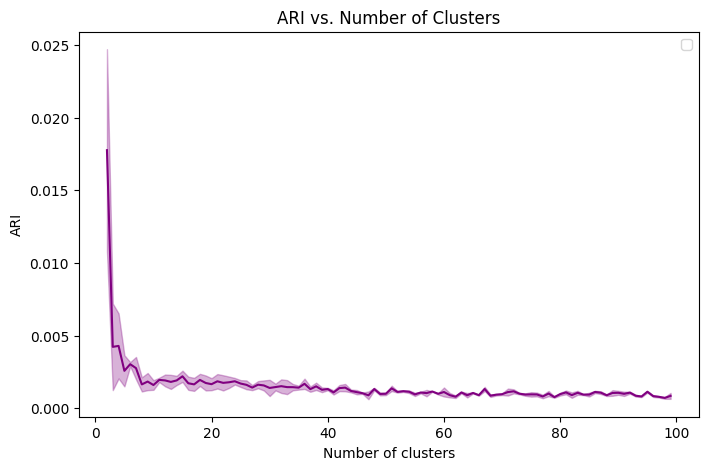

In [57]:
clusters_num = range(2,100)
ari_means = np.array([np.mean(adjusted_rand_adap[c]) for c in clusters_num])
ari_stds = np.array([np.std(adjusted_rand_adap[c]) for c in clusters_num])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(clusters_num, ari_means, color="purple")
plt.fill_between(clusters_num, ari_means - ari_stds, ari_means + ari_stds, color="purple", alpha=0.3)

# Labels & Legend
plt.xlabel("Number of clusters")
plt.ylabel("ARI")
plt.legend()
plt.title("ARI vs. Number of Clusters")
plt.show()

In [29]:
seeds = [42, 10, 100]  # Example seed values
clusters_num = range(2,100)


# Features extracted earlier
features_dict = {
    42: combined_features_42/ np.linalg.norm(combined_features_42, axis=1,  keepdims=True),
    10: combined_features_10 / np.linalg.norm(combined_features_10, axis=1,  keepdims=True),
    100: combined_features_100 / np.linalg.norm(combined_features_100, axis=1,  keepdims=True)
}

# Dictionary to store cluster assignments
clusters = {}

# Apply KMeans clustering on the extracted features for each seed
for s in seeds:
    clusters[s] = {}  # Initialize dictionary for each seed
    features = features_dict[s]  # Get the corresponding features

    for c in clusters_num:
        kmeans = KMeans(n_clusters=c, random_state=s, n_init=10)
        clusters[s][c] = kmeans.fit_predict(features)

# Compute Adjusted Rand Index (ARI) between different seeds for each cluster count
adjusted_rand_adap_norm = {}

for n_clust in tqdm(clusters[42].keys()):  # Iterate over cluster numbers
    adjusted_rand_adap_norm[n_clust] = []

    for seed1, seed2 in combinations(seeds, 2):
        ari_score = adjusted_rand_score(clusters[seed1][n_clust], clusters[seed2][n_clust])
        adjusted_rand_adap_norm[n_clust].append(ari_score)

# Print ARI results
for n_clust, scores in adjusted_rand_adap_norm.items():
    print(f"Clusters: {n_clust}, ARI Scores: {scores}")

100%|██████████| 98/98 [00:00<00:00, 184.17it/s]

Clusters: 2, ARI Scores: [0.01778641936769212, 0.0218445472073451, 0.020477040636835305]
Clusters: 3, ARI Scores: [0.015574460272534462, 0.012221046285095676, 0.015636097467859673]
Clusters: 4, ARI Scores: [0.015287523569839083, 0.014064667997417166, 0.014952761839898594]
Clusters: 5, ARI Scores: [0.029648957312838887, 0.039576091870321954, 0.03857567339045307]
Clusters: 6, ARI Scores: [0.047346204304191494, 0.050369025223952583, 0.050178774257868625]
Clusters: 7, ARI Scores: [0.04646358519332005, 0.049262878368717886, 0.0490725052412926]
Clusters: 8, ARI Scores: [0.04633616657163336, 0.0480340902265411, 0.04634491622118668]
Clusters: 9, ARI Scores: [0.03942885693900325, 0.04002101124517177, 0.04881961798267916]
Clusters: 10, ARI Scores: [0.05012595219300723, 0.04959157403409273, 0.04830435500954357]
Clusters: 11, ARI Scores: [0.05291944932809528, 0.04933951851296839, 0.04917419543025484]
Clusters: 12, ARI Scores: [0.039751151331785556, 0.04070049176780498, 0.050495853386009135]
Cluste

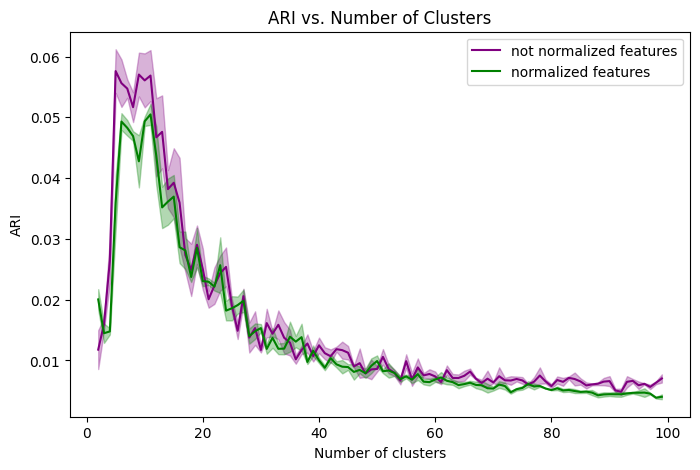

In [32]:
clusters_num = range(2,100)
ari_means = np.array([np.mean(adjusted_rand_adap[c]) for c in clusters_num])
ari_stds = np.array([np.std(adjusted_rand_adap[c]) for c in clusters_num])
ari_means_norm = np.array([np.mean(adjusted_rand_adap_norm[c]) for c in clusters_num])
ari_stds_norm = np.array([np.std(adjusted_rand_adap_norm[c]) for c in clusters_num])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(clusters_num, ari_means, color="purple", label='not normalized features')
plt.fill_between(clusters_num, ari_means - ari_stds, ari_means + ari_stds, color="purple", alpha=0.3)
plt.plot(clusters_num, ari_means_norm, color="green", label='normalized features')
plt.fill_between(clusters_num, ari_means_norm - ari_stds_norm, ari_means_norm + ari_stds_norm, color="green", alpha=0.3)

# Labels & Legend
plt.xlabel("Number of clusters")
plt.ylabel("ARI")
plt.legend()
plt.title("ARI vs. Number of Clusters")
plt.show()

TSNE plot with cluster centers

<Figure size 640x800 with 0 Axes>

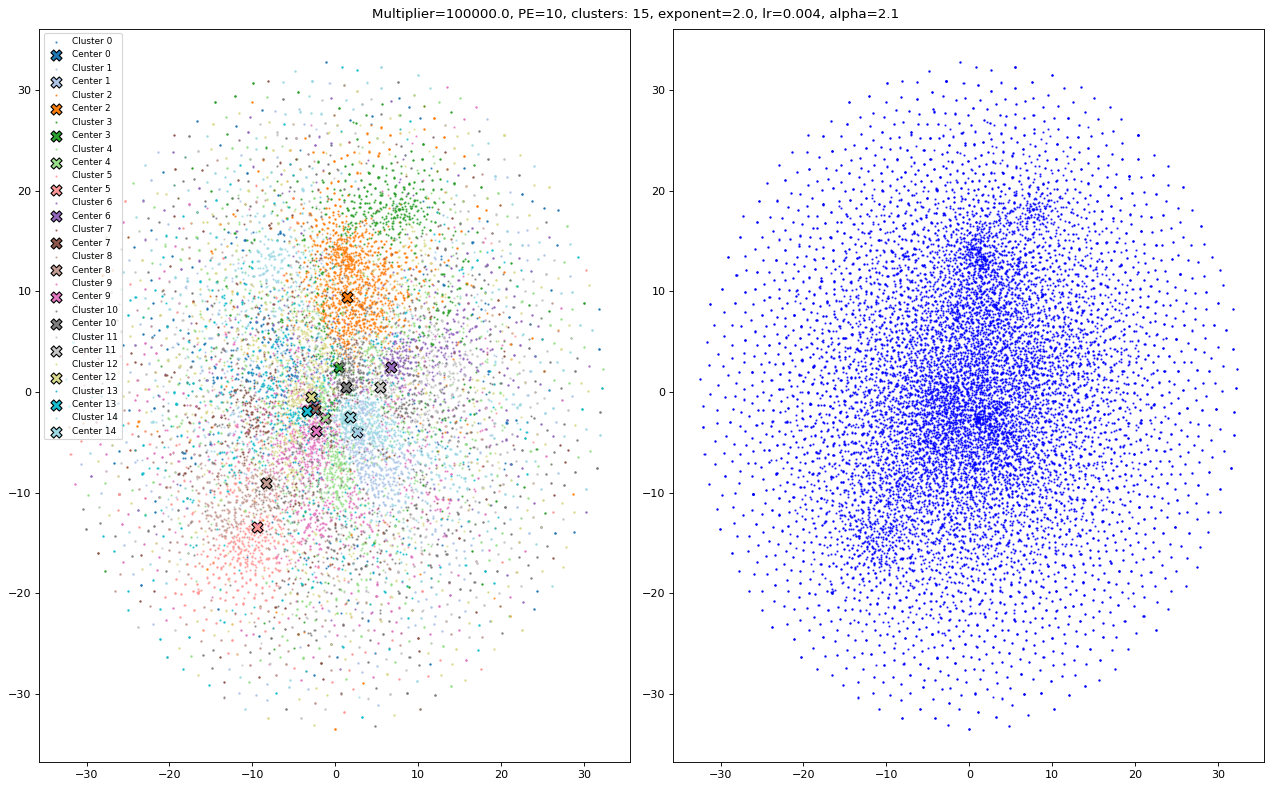

In [108]:
perplexity = n / 100
lr = n / 12

np.random.seed(42)
plt.figure(figsize=(8,10), dpi=80)
fig, axes = plt.subplots(1,2, figsize=(16, 10), dpi=80)  # 2x4 grid in each figure


unique_values = np.unique(predictions_subset)
colors = plt.cm.get_cmap("tab20", len(unique_values))
color_map = {label: colors(i) for i, label in enumerate(unique_values)}

combined_data = np.vstack([combined_features, cluster_centers])  # Stack features with centers
Y = combined_data / np.linalg.norm(combined_data, axis=1,  keepdims=True)
combined_data = Y.copy()

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

# Split the result back into original points and cluster centers
n_samples = combined_features.shape[0]
embedded_points = embedded_data[:n_samples]  # First part corresponds to data points
embedded_centers = embedded_data[n_samples:]  # Last part corresponds to cluster centers

# **Subplot 1: Colored Clusters**
for value in unique_values:
    cluster_mask = predictions_subset == value
    axes[0].scatter(
        embedded_points[cluster_mask, 0],
        embedded_points[cluster_mask, 1],
        c=[color_map[value]],  # Mapped color
        label=f'Cluster {value}',
        alpha=0.7,
        s=1,
    )
    
    axes[0].scatter(
        embedded_centers[value, 0],
        embedded_centers[value, 1],
        c=[color_map[value]],
        marker='X',
        s=100,
        edgecolor='black',
        label=f'Center {value}'
    )
    
axes[0].legend(fontsize=8, loc='upper left',)

# **Subplot 2: Single-Color**
axes[1].scatter(
    embedded_points[:, 0],
    embedded_points[:, 1],
    c="blue",  # Single color
    alpha=0.7,
    s=1,
)

fig.suptitle(f'Multiplier={multiplier}, PE={pretrain_epoch}, clusters: {clusters}, exponent={exponent}, lr={lr_model}, alpha={alpha}')

plt.savefig(f'plots/tsne_model_wo_rotation_{path_ending}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi

# Adjust layout and show
plt.tight_layout()
plt.show()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


Cluster 0: Mask shape = (14000,), Points = 634
Cluster 1: Mask shape = (14000,), Points = 934
Cluster 2: Mask shape = (14000,), Points = 1491
Cluster 3: Mask shape = (14000,), Points = 896
Cluster 4: Mask shape = (14000,), Points = 1263
Cluster 5: Mask shape = (14000,), Points = 720
Cluster 6: Mask shape = (14000,), Points = 693
Cluster 7: Mask shape = (14000,), Points = 662
Cluster 8: Mask shape = (14000,), Points = 603
Cluster 9: Mask shape = (14000,), Points = 1105
Cluster 10: Mask shape = (14000,), Points = 1200
Cluster 11: Mask shape = (14000,), Points = 763
Cluster 12: Mask shape = (14000,), Points = 1181
Cluster 13: Mask shape = (14000,), Points = 721
Cluster 14: Mask shape = (14000,), Points = 1134


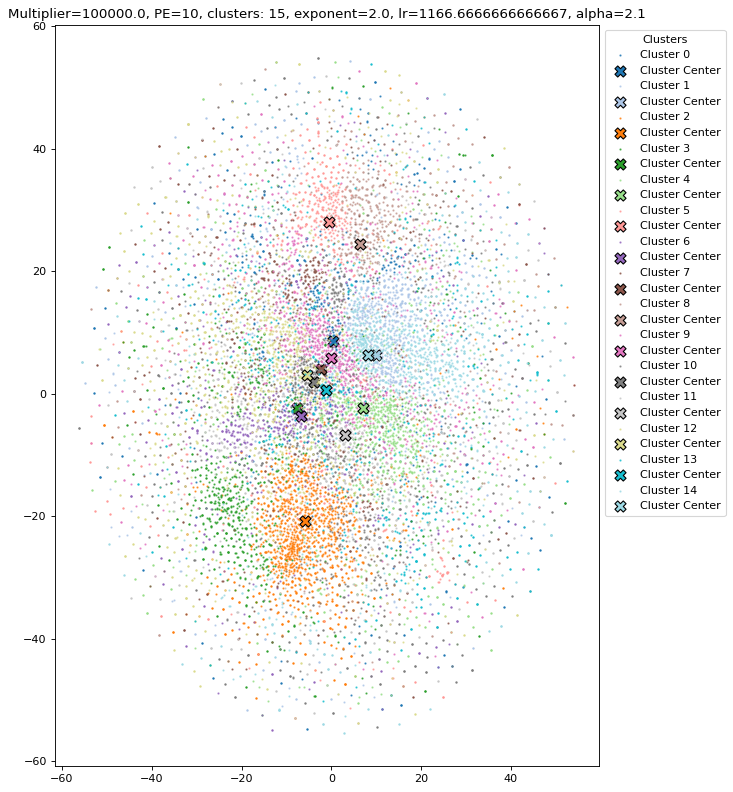

In [109]:
perplexity = 100
n/100
#[30, 50, 100, n/100]
learning_rates = [n/12]
#[10,100,1000,n/12]
lr = n/12

plt.figure(figsize=(7.5,10), dpi=80)
print((unique_values))

colors = plt.cm.get_cmap("tab10", len(unique_values))  # Define colors for clusters

# Define colors explicitly
unique_values = np.unique(predictions_subset)
colors = plt.cm.get_cmap("tab20", len(unique_values))
color_map = {label: colors(i) for i, label in enumerate(unique_values)}

combined_data = np.vstack([combined_features, cluster_centers])  # Stack features with centers

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

# Split the result back into original points and cluster centers
n_samples = combined_features.shape[0]
embedded_points = embedded_data[:n_samples]  # First part corresponds to data points
embedded_centers = embedded_data[n_samples:]  # Last part corresponds to cluster centers

for value in unique_values:
    cluster_mask = predictions_subset == value
    print(f"Cluster {value}: Mask shape = {cluster_mask.shape}, Points = {cluster_mask.sum()}")
    
    plt.scatter(
        embedded_points[cluster_mask, 0],
        embedded_points[cluster_mask, 1],
        c=[color_map[value]],  # Mapped color
        label=f'Cluster {value}',
        alpha=0.7,
        s=1,
    )
    
    plt.scatter(
        embedded_centers[value][0],
        embedded_centers[value][1],
        c=[color_map[value]],  # Mapped color
        marker='X',
        s=100,
        edgecolor='black',
        label='Cluster Center'
    )
    
plt.title(f'Multiplier={multiplier}, PE={pretrain_epoch}, clusters: {clusters}, exponent={exponent}, lr={lr}, alpha={alpha}')

# Adjust layout for better spacing
plt.tight_layout()

# Add legend automatically from the scatter plot
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.savefig(f'plots/tsne_model_wo_rotation_{path_ending}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi
plt.show()

## Color by mice

<Figure size 640x800 with 0 Axes>

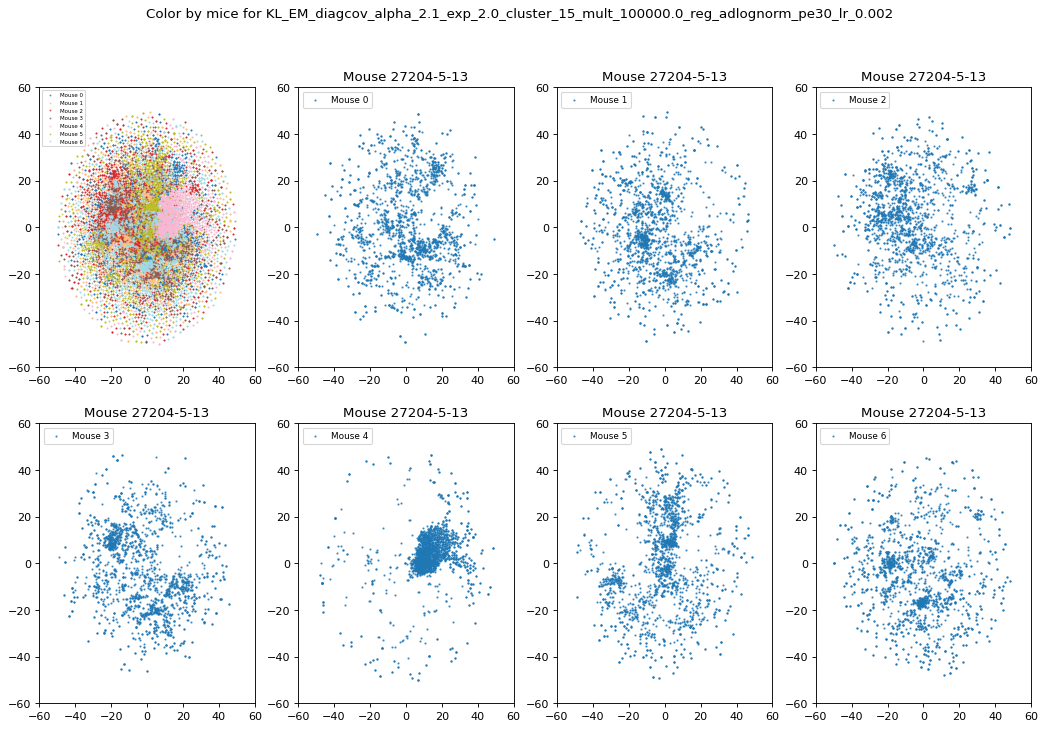

In [52]:
perplexity = n/100
lr = n/12

plt.figure(figsize=(8,10), dpi=80)

# Create a new figure for each plot
fig, ax = plt.subplots(2, 4, figsize=(16, 10), dpi=80)  # 2x4 grid in each figure

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on combined data

# Parameters
total_points = len(embedded_points)  # Total number of points
group_size = 2000  # Group size for each color
num_groups = 7

colors = plt.cm.get_cmap("tab20", num_groups)  # Dynamically create colormap
color_map = {group: colors(group) for group in range(num_groups)}
point_groups = np.arange(total_points) // group_size  # Assign each point a group


# Plot points with group colors
for group in range(num_groups):
    group_mask = point_groups == group

    ax[0,0].scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        c=[color_map[group]],  # Use color from the colormap
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=0.5,  # Size of points
    )
    ax[0,0].set_xlim(-60, 60)
    ax[0,0].set_ylim(-60, 60)
    ax[0,0].legend(fontsize=5, loc='upper left')


# Plot points with group colors
for group in range(num_groups):
    idx = group + 1
    
    group_mask = point_groups == group
    # Find the subplot position
    row = idx // 4  # Calculate row index (0 or 1)
    col = idx % 4   # Calculate column index (0 to 3)

    # Select the subplot location
    ax[row, col].scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=1,  # Size of points
    )

    # Customize the plot
    ax[row, col].set_title(f'Mouse {k}')
    ax[row, col].set_xlim(-60, 60)
    ax[row, col].set_ylim(-60, 60)
    ax[row, col].legend(fontsize=8, loc='upper left',)


plt.suptitle(f'Color by mice for {path_ending}')
# plt.title(f'Color by mice with Perplexity={perplexity}, Multiplier={multiplier}, SE={starting_epcoch}, clusters: {clusters}, exponent={exponent}')
#plt.legend()
plt.show()

In [ ]:
perplexity = n/100
lr = n/12

plt.figure(figsize=(8,10), dpi=80)

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on combined data

# Parameters
total_points = len(embedded_points)  # Total number of points
group_size = 2000  # Group size for each color
num_groups = 7

colors = plt.cm.get_cmap("tab20", num_groups)  # Dynamically create colormap
color_map = {group: colors(group) for group in range(num_groups)}
point_groups = np.arange(total_points) // group_size  # Assign each point a group


# Plot points with group colors
for group in range(num_groups):
    group_mask = point_groups == group

    plt.scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        c=[color_map[group]],  # Use color from the colormap
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=0.5,  # Size of points
    )
    plt.legend(fontsize=5, loc='upper left')

### Plots for indivual mice

In [39]:
perplexity = n/100
lr = n/12

for idx, (k, readout) in enumerate(model.readout.items()):
    idx = idx +1
    # Extract features and convert to numpy
    features = readout.features.cpu().detach().squeeze().T.numpy()

    # Perform t-SNE embedding
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_points = tsne.fit_transform(features)

    # Find the subplot position
    row = idx // 4  # Calculate row index (0 or 1)
    col = idx % 4   # Calculate column index (0 to 3)

    # Select the subplot location
    ax[row, col].scatter(
        embedded_points[:, 0],  # X coordinates
        embedded_points[:, 1],  # Y coordinates
        label=f'Mouse {k}',
        alpha=0.7,  # Transparency
        s=1,  # Size of points
    )

    # Customize the plot
    ax[row, col].set_title(f'Mouse {k}')
    ax[row, col].set_xlim(-0.3, 0.3)
    ax[row, col].set_ylim(-0.3, 0.3)
    ax[row, col].legend(fontsize=8)

plt.show()
    

<Figure size 640x800 with 0 Axes>

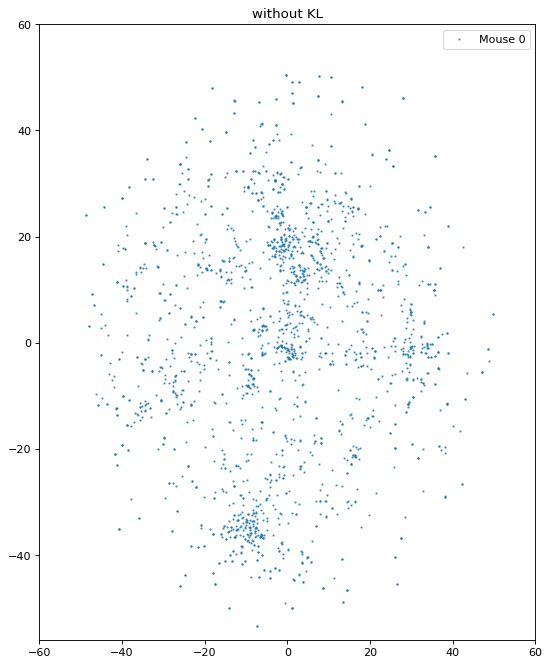

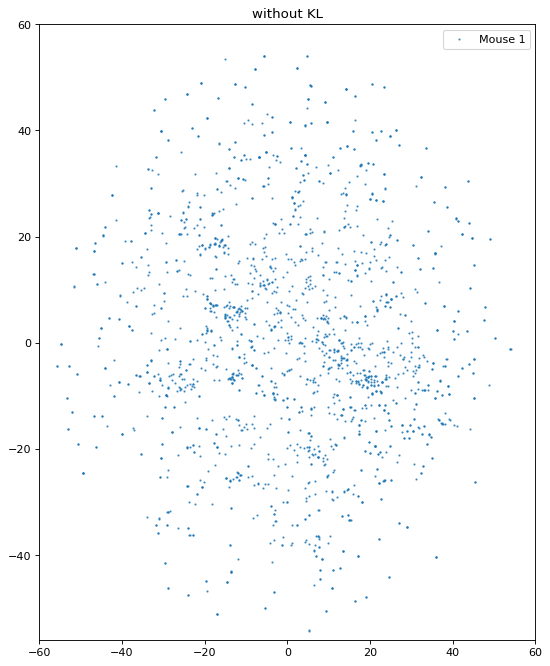

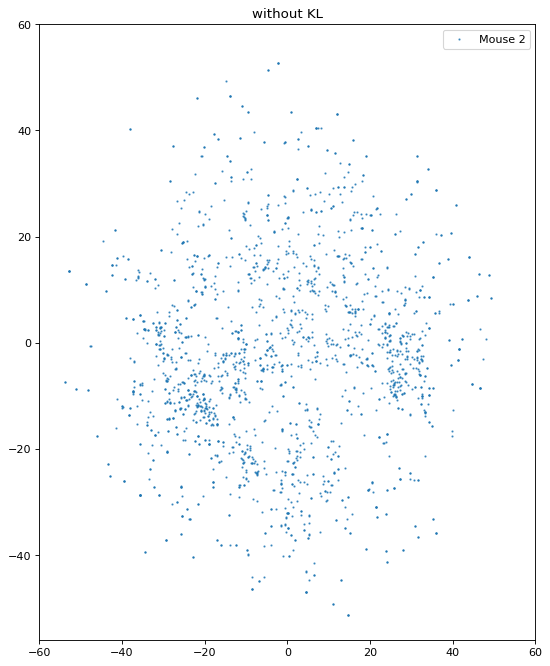

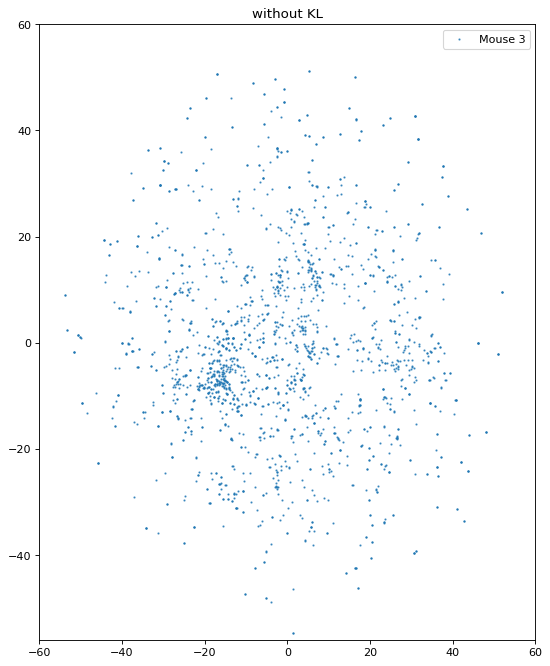

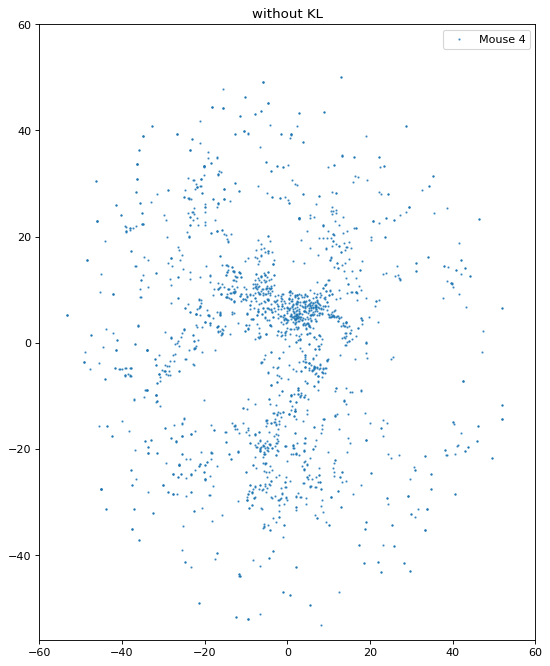

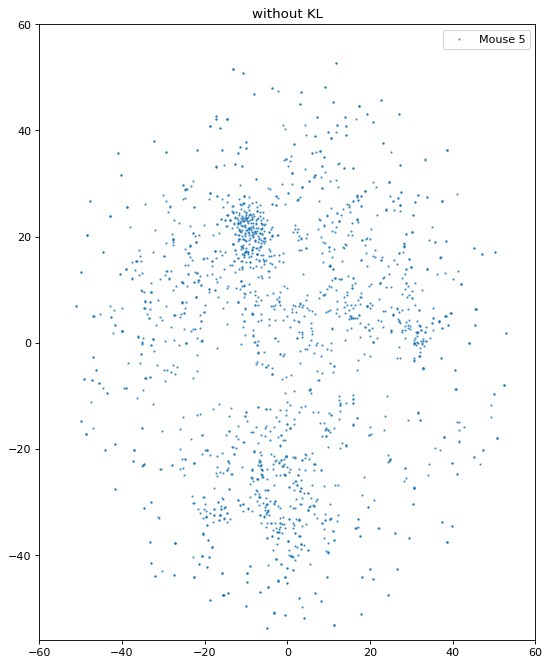

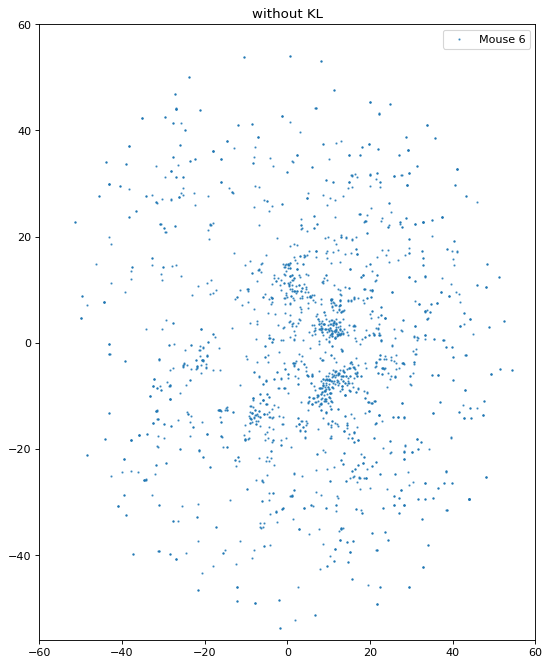

In [14]:
perplexity = n/100
lr = n/12

plt.figure(figsize=(8,10), dpi=80)

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
embedded_points = tsne.fit_transform(combined_features)  # Run on combined data

# Parameters
total_points = len(embedded_points)  # Total number of points
group_size = 2000  # Group size for each color
num_groups = 7

colors = plt.cm.get_cmap("tab20", num_groups)  # Dynamically create colormap
color_map = {group: colors(group) for group in range(num_groups)}
point_groups = np.arange(total_points) // group_size  # Assign each point a group


# Plot points with group colors
for group in range(num_groups):
    plt.figure(figsize=(8,10), dpi=80)
    
    group_mask = point_groups == group

    plt.scatter(
        embedded_points[group_mask, 0],  # X coordinates of points in the group
        embedded_points[group_mask, 1],  # Y coordinates of points in the group
        label=f'Mouse {group}',
        alpha=0.7,  # Transparency
        s=1,  # Size of points
    )

    plt.title('without KL')
    plt.xlim(-60, 60)
    plt.ylim(-56, 60)
    # plt.title(f'Color by mice with Perplexity={perplexity}, Multiplier={multiplier}, SE={starting_epcoch}, clusters: {clusters}, exponent={exponent}')
    plt.legend()
    plt.show()

Code for predictions

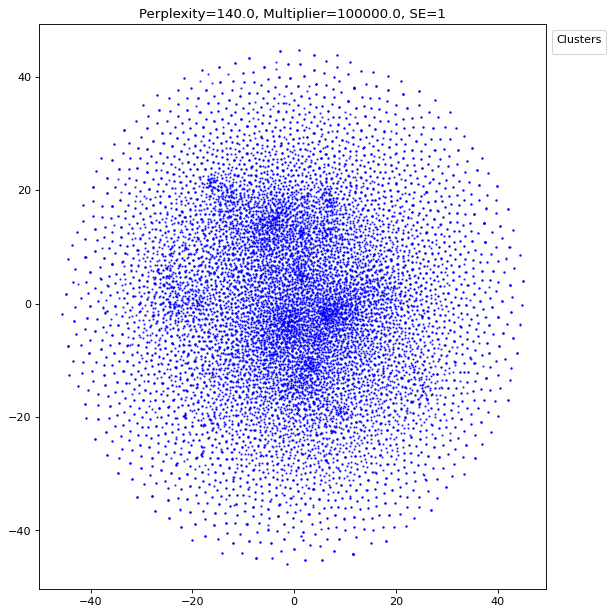

In [13]:
# Fixed Perplexity and Learning Rate
perplexity_values = [n / 100]
learning_rates = [n / 12]
lr = n / 12

# Set up the plot
plt.figure(figsize=(20, 15), dpi=80)

for i, perplexity in enumerate(perplexity_values):
    # Combine features and cluster centers for t-SNE
    combined_data = np.vstack([combined_features, cluster_centers])  # Stack features with centers
    
    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

    # Split the result back into original points and cluster centers
    n_samples = combined_features.shape[0]
    embedded_points = embedded_data[:n_samples]  # First part corresponds to data points
    embedded_centers = embedded_data[n_samples:]  # Last part corresponds to cluster centers

    # Create a subplot for each perplexity
    plt.subplot(2, 3, i + 1)  # Correct subplot indexing

    # Define a single color for all clusters
    single_color = 'blue'

    for label in unique_values:
        cluster_mask = predictions_subset == label  # Mask for the current cluster
        
        # Scatter plot for all points (same color)
        plt.scatter(
            embedded_points[cluster_mask, 0], embedded_points[cluster_mask, 1],
            c=single_color, alpha=0.7, s=1
        )
        # Plot cluster centers (same color, marked as X)
        '''
        plt.scatter(
            embedded_centers[label][0], embedded_centers[label][1], 
            c=single_color, marker='X', s=100, edgecolor='black'
        )
        '''

    
    plt.title(f'Perplexity={perplexity}, Multiplier={multiplier}, SE={starting_epcoch}')

# Adjust layout for better spacing
plt.tight_layout()

# Add legend automatically from the scatter plot
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
#plt.savefig(f'plots/tsne_model_wo_rotation_adaptlognorm_mult_{multiplier}se{starting_epcoch}_we{dec_wamup_epcoh}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi
plt.show()

Giff

In [ ]:
# Create a directory to store the individual heatmap frames
os.makedirs('heatmap_frames', exist_ok=True)

# Assuming cluster_centers_epochs is of shape (time, num_clusters, num_features)
time = cluster_centers_epochs.shape[0]
num_clusters = cluster_centers_epochs.shape[1]

# Loop to calculate distances and plot the heatmap for each epoch
for batch in range(time):
    # Step 1: Calculate the distance matrix for the current batch
    distance_matrix = np.zeros((num_clusters, num_clusters))
    for i in range(num_clusters):
        for j in range(num_clusters):
            if i != j:
                distance_matrix[i, j] = np.linalg.norm(cluster_centers_epochs[batch][i] - cluster_centers_epochs[batch][j])  # Euclidean distance

    # Step 2: Create a DataFrame to make it more interpretable
    distance_df = pd.DataFrame(distance_matrix, 
                               index=[f'Cluster {i}' for i in range(num_clusters)], 
                               columns=[f'Cluster {j}' for j in range(num_clusters)])

    # Step 3: Plot the distance table as a heatmap
    plt.figure(figsize=(10, 8), dpi=80)
    sns.heatmap(distance_df, annot=True, fmt=".2f", cmap="viridis", cbar=True)
    plt.title(f'Cluster Center Distances (Epoch {batch+1}/{time})')
    plt.xlabel('Cluster Number (j)')
    plt.ylabel('Cluster Number (i)')

    # Save each frame as an image
    frame_path = f'heatmap_frames/heatmap_epoch_{batch}.png'
    plt.savefig(frame_path, dpi=150, bbox_inches='tight')
    plt.close()  # Close the figure to free up memory

# Step 4: Create the GIF from saved frames
frames = []
for batch in range(time):
    frame_path = f'heatmap_frames/heatmap_epoch_{batch}.png'
    image = Image.open(frame_path)
    frames.append(image)

# Save the GIF
gif_path = 'plots/cluster_distance_heatmap.gif'
frames[0].save(
    gif_path, 
    save_all=True, 
    append_images=frames[1:], 
    duration=500,  # Duration of each frame in milliseconds
    loop=0  # Loop forever
)

print(f"GIF saved at {gif_path}")

TSNE plot without cluster centers

In [7]:
perplexity_values = 50
#[n/100]
#[30, 50, 100, n/100]
learning_rates = [n/12]
#[10,100,1000,n/12]
lr = n/12

# Create a plot for each perplexity value
plt.figure(figsize=(20, 20), dpi=80)

for i, perplexity in enumerate(perplexity_values):
    #for j, lr in enumerate(learning_rates):
        # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)  # Adjust perplexity as needed
    embedded_data = tsne.fit_transform(combined_features)

    # Create a subplot for each perplexity
    plt.subplot(2,3, i + 1)  # Correct subplot indexing
    for label in unique_values:
        cluster_mask = predictions_subset == label  # Mask for the current cluster
        plt.scatter(
            embedded_data[cluster_mask, 0], embedded_data[cluster_mask, 1],
            c=[label_to_color[label]], label=f'Cluster {label}', alpha=0.7, s=1
        )
    plt.title(f'Perplexity={perplexity}')

# Adjust layout for better spacing
plt.tight_layout()

# Add legend automatically from the scatter plot
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.show()


TypeError: 'int' object is not iterable

<Figure size 1600x1600 with 0 Axes>

In [19]:
plt.savefig(f'plots/tsne_model_wo_rotation_adaptlognorm_mult_{multiplier}se{dec_starting_epcoch}_we{dec_wamup_epcoh}.png', dpi=300, bbox_inches='tight')  # Save as PNG with hi
plt.show()

<Figure size 640x480 with 0 Axes>